# Linear Regression Notebook - MLflow Parameter & Metric Logging

This notebook demonstrates:
- Logging parameters with `mlflow.log_param()` and `mlflow.log_params()`
- Logging metrics with `mlflow.log_metric()`
- Comparing multiple runs with different hyperparameters

**Dataset:** California Housing (sklearn built-in)  
**Model:** Ridge Regression (L2 regularization)  
**Task:** Predict median house value with different alpha values

In [6]:
import mlflow
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
mlflow.set_tracking_uri("file:./mlruns")

## 1. Load and Prepare Data

In [7]:
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")

Training samples: 16512
Test samples: 4128
Number of features: 8


## 2. Train Multiple Models with Different Alphas

We'll train Ridge Regression with different regularization strengths (alpha values) and log each experiment to MLflow.

In [8]:
# Set experiment
mlflow.set_experiment("california-housing-ridge-regression")

# Different alpha values to compare
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    with mlflow.start_run(run_name=f"ridge-alpha-{alpha}"):
        # Log parameters
        mlflow.log_param("model_type", "Ridge")
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("scaler", "StandardScaler")
        
        # Train model
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Log metrics
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2_score", r2)
        
        # Log model
        mlflow.sklearn.log_model(model, "ridge-model")
        
        # Store results for comparison
        results.append({
            "alpha": alpha,
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2_score": r2
        })
        
        print(f"Alpha: {alpha:>6} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

/Users/harsha/Desktop/MLOps Labs/MLOps_Labs/lab4/mlflow_lab1/mlflow_lab1_env/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/14 22:03:46 INFO mlflow.tracking.fluent: Experiment with name 'california-housing-ridge-regression' does not exist. Creating a new experiment.
2026/03/14 22:03:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 22:03:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute ar

Alpha:   0.01 | RMSE: 0.7456 | MAE: 0.5332 | R2: 0.5758


2026/03/14 22:03:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 22:03:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Alpha:    0.1 | RMSE: 0.7456 | MAE: 0.5332 | R2: 0.5758


2026/03/14 22:03:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 22:03:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Alpha:    1.0 | RMSE: 0.7456 | MAE: 0.5332 | R2: 0.5758


2026/03/14 22:03:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 22:03:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Alpha:   10.0 | RMSE: 0.7453 | MAE: 0.5331 | R2: 0.5761
Alpha:  100.0 | RMSE: 0.7438 | MAE: 0.5330 | R2: 0.5778


## 3. Compare Results

In [9]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Identify the best model
best_idx = results_df['r2_score'].idxmax()
print(f"\nBest model: Ridge with alpha={results_df.loc[best_idx, 'alpha']} "
      f"(R2: {results_df.loc[best_idx, 'r2_score']:.4f})")


=== Model Comparison ===
 alpha      mse     rmse      mae  r2_score
  0.01 0.555891 0.745581 0.533200  0.575788
  0.10 0.555888 0.745579 0.533199  0.575791
  1.00 0.555855 0.745557 0.533193  0.575816
 10.00 0.555535 0.745342 0.533138  0.576060
100.00 0.553266 0.743819 0.533014  0.577791

Best model: Ridge with alpha=100.0 (R2: 0.5778)


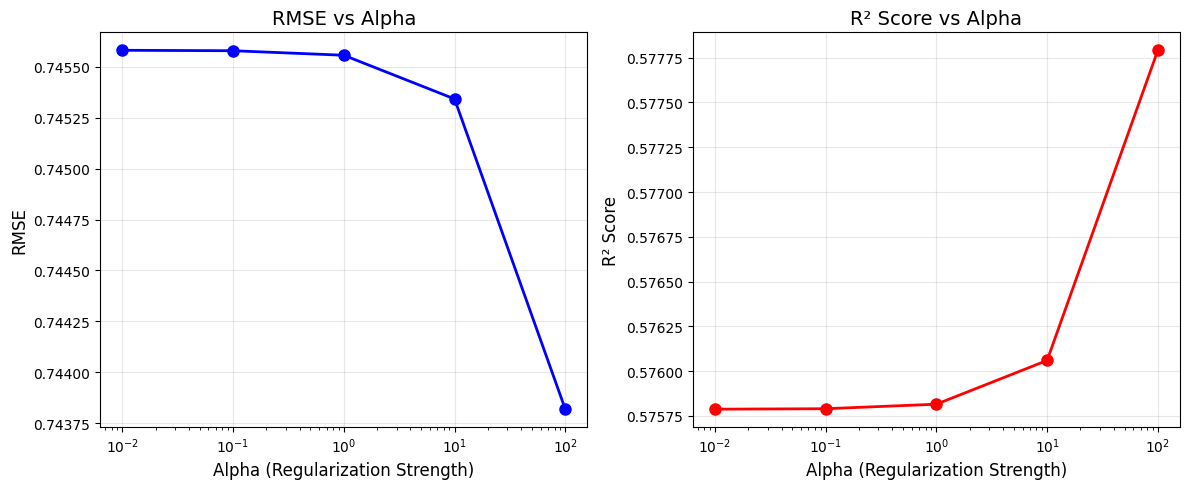

Plot saved as ridge_comparison.png


In [10]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE vs Alpha
axes[0].plot(results_df['alpha'], results_df['rmse'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('RMSE vs Alpha', fontsize=14)
axes[0].grid(True, alpha=0.3)

# R2 vs Alpha
axes[1].plot(results_df['alpha'], results_df['r2_score'], 'ro-', linewidth=2, markersize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('R² Score vs Alpha', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as ridge_comparison.png")

## 4. View in MLflow UI

Run in terminal:
```bash
mlflow ui --port 5001
```

Open http://127.0.0.1:5001 to compare all runs side by side.